# Imports


In [19]:
import numpy as np
import pandas as pd
import os
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.metrics.pairwise import cosine_similarity

os.makedirs("fusion_indexes_all", exist_ok=True)
os.makedirs("projection_matrices_all", exist_ok=True)


# Load Embeddings
# Vision embeddings (8091 × Dv)
Xv_resnet = np.load("/home/aysel/tfe/TFE_Data/Unimodal_Results/Flickr8k/vision/resnet50/embeddings.npy")
Xv_vit       = np.load("/home/aysel/tfe/TFE_Data/Unimodal_Results/Flickr8k/vision/vit/embeddings.npy")

# Text embeddings (40455 × Dt)
Xt_gpt2_raw = np.load("/home/aysel/tfe/TFE_Data/Unimodal_Results/Flickr8k/text/gpt2/embeddings.npy")


# Load Embeddings
# Vision embeddings (8091 × Dv)
Xv_mobilenet = np.load("/home/aysel/tfe/TFE_Data/Unimodal_Results/Flickr8k/vision/mobilenet_v3/embeddings.npy")
Xv_pvt       = np.load("/home/aysel/tfe/TFE_Data/Unimodal_Results/Flickr8k/vision/pvt/embeddings.npy")

# Text embeddings (40455 × Dt)
Xt_roberta_raw = np.load("/home/aysel/tfe/TFE_Data/Unimodal_Results/Flickr8k/text/roberta/embeddings.npy")
Xt_bert_raw    = np.load("/home/aysel/tfe/TFE_Data/Unimodal_Results/Flickr8k/text/bert/embeddings.npy")


def group_captions(Xt, k=5):
    N = Xt.shape[0] // k
    return Xt.reshape(N, k, -1).mean(axis=1)



Xt_roberta = group_captions(Xt_roberta_raw)
Xt_bert    = group_captions(Xt_bert_raw)
Xt_gpt2 = group_captions(Xt_gpt2_raw)

vision_models = {
    "MobileNetV3": Xv_mobilenet,
    "PVT": Xv_pvt,
    
    "ResNet50": Xv_resnet,
    "Vit": Xv_vit
}

text_models = {
    "RoBERTa": Xt_roberta,
    "BERT": Xt_bert,
    
    "GPT2": Xt_gpt2
}

raw_text_models = {
    "RoBERTa": Xt_roberta_raw,
    "BERT": Xt_bert_raw,
    
    "GPT2": Xt_gpt2_raw

}


In [127]:
# Projection Methods
from sklearn.cross_decomposition import CCA


def proj_random_shared(Dv, Dt, dim):
    """
    Johnson–Lindenstrauss random projection into a shared latent space.
    Dv = vision embedding dimension
    Dt = text embedding dimension
    dim = shared latent dimension
    """
    Wv = np.random.randn(Dv, dim)
    Wt = np.random.randn(Dt, dim)
    return Wv, Wt


def proj_pca_shared(Xv_pairs, Xt_pairs, dim):
    dim = min(dim, Xv_pairs.shape[1], Xt_pairs.shape[1])
    pca_v = PCA(n_components=dim).fit(Xv_pairs)
    pca_t = PCA(n_components=dim).fit(Xt_pairs)
    return pca_v.components_.T, pca_t.components_.T

def proj_cca_shared(Xv_pairs, Xt_pairs, dim):
    # PCA pre-reduction
    pca_dim = min(256, Xv_pairs.shape[1], Xt_pairs.shape[1])
    pca_v = PCA(n_components=pca_dim).fit(Xv_pairs)
    pca_t = PCA(n_components=pca_dim).fit(Xt_pairs)

    Xv_p = pca_v.transform(Xv_pairs)
    Xt_p = pca_t.transform(Xt_pairs)

    cca = CCA(n_components=dim, max_iter=2000)
    cca.fit(Xv_p, Xt_p)

    # Build final projection matrices
    Wv = pca_v.components_.T @ cca.x_weights_
    Wt = pca_t.components_.T @ cca.y_weights_

    return Wv, Wt


In [128]:
# Fusion Functions
# -------------------------
# INTERMEDIATE FUSION
# -------------------------

def fuse_concat(X1, X2):
    return np.concatenate([X1, X2], axis=1)

def fuse_add(X1, X2):
    d = min(X1.shape[1], X2.shape[1])
    return X1[:, :d] + X2[:, :d]

def fuse_gated(X1, X2, alpha=0.5):
    return alpha * X1 + (1 - alpha) * X2

def fuse_mul(X1, X2):
    d = min(X1.shape[1], X2.shape[1])
    return X1[:, :d] * X2[:, :d]


In [129]:

# Execution

projection_methods = {
    "random": proj_random_shared,
    "pca_shared": proj_pca_shared,
    "cca_shared": proj_cca_shared
}

fusion_methods = {
    "concat": fuse_concat,
    "add": fuse_add,
    "gated": fuse_gated,
    "mul": fuse_mul
}

records = []
LATENT_DIM = 128
N_TRAIN = 2000

for v_name, Xv in vision_models.items():
    for t_name, Xt in text_models.items():

        Xt_raw = raw_text_models[t_name]

        # Build true aligned pairs (40455)
        Xv_pairs_full = np.repeat(Xv, 5, axis=0)
        Xt_pairs_full = Xt_raw

        idx = np.random.choice(40455, N_TRAIN, replace=False)

        Xv_pairs = Xv_pairs_full[idx]
        Xt_pairs = Xt_pairs_full[idx]


        for proj_name, proj_func in projection_methods.items():

            print(f"\n=== {v_name} × {t_name} — {proj_name} ===")

            # Learn shared projection matrices
            if proj_name == "random":
                Wv, Wt = proj_func(Xv.shape[1], Xt.shape[1], LATENT_DIM)
            else:
                Wv, Wt = proj_func(Xv_pairs, Xt_pairs, LATENT_DIM)

            # Project all embeddings
            Xv_proj = Xv @ Wv
            Xt_proj = Xt @ Wt
            Xt_raw_proj = Xt_raw @ Wt

            # Repeat image projections for raw captions
            Xv_proj_rep = np.repeat(Xv_proj, 5, axis=0)

            # Save projection matrices
            Wv_path = f"projection_matrices/Wv_{v_name}_{t_name}_{proj_name}.npy"
            Wt_path = f"projection_matrices/Wt_{v_name}_{t_name}_{proj_name}.npy"
            np.save(Wv_path, Wv)
            np.save(Wt_path, Wt)

            # Build fusion indexes
            for f_name, f_func in fusion_methods.items():

                F_img = f_func(Xv_proj, Xt_proj)
                F_cap = f_func(Xv_proj_rep, Xt_raw_proj)

                img_path = f"fusion_indexes/{v_name}_{t_name}_{proj_name}_{f_name}_image.npy"
                cap_path = f"fusion_indexes/{v_name}_{t_name}_{proj_name}_{f_name}_caption.npy"

                np.save(img_path, F_img)
                np.save(cap_path, F_cap)

                records.append({
                    "vision_model": v_name,
                    "text_model": t_name,
                    "projection": proj_name,
                    "fusion": f_name,
                    "latent_dim": LATENT_DIM,
                    "image_index_path": img_path,
                    "caption_index_path": cap_path,
                    "Wv_path": Wv_path,
                    "Wt_path": Wt_path
                })

df_meta = pd.DataFrame(records)
df_meta.to_csv("fusion_indexes/fusion_index_metadata.csv", index=False)
df_meta


=== mobilenet_v3 × roberta — random ===

=== mobilenet_v3 × roberta — pca_shared ===

=== mobilenet_v3 × roberta — cca_shared ===

=== mobilenet_v3 × bert — random ===

=== mobilenet_v3 × bert — pca_shared ===

=== mobilenet_v3 × bert — cca_shared ===

=== pvt × roberta — random ===

=== pvt × roberta — pca_shared ===

=== pvt × roberta — cca_shared ===

=== pvt × bert — random ===

=== pvt × bert — pca_shared ===

=== pvt × bert — cca_shared ===


,vision_model,text_model,projection,fusion,latent_dim,image_index_path,caption_index_path,Wv_path,Wt_path
0,mobilenet_v3,roberta,random,concat,128,fusion_indexes/mobilenet_v3_roberta_random_con...,fusion_indexes/mobilenet_v3_roberta_random_con...,projection_matrices/Wv_mobilenet_v3_roberta_ra...,projection_matrices/Wt_mobilenet_v3_roberta_ra...
1,mobilenet_v3,roberta,random,add,128,fusion_indexes/mobilenet_v3_roberta_random_add...,fusion_indexes/mobilenet_v3_roberta_random_add...,projection_matrices/Wv_mobilenet_v3_roberta_ra...,projection_matrices/Wt_mobilenet_v3_roberta_ra...
2,mobilenet_v3,roberta,random,gated,128,fusion_indexes/mobilenet_v3_roberta_random_gat...,fusion_indexes/mobilenet_v3_roberta_random_gat...,projection_matrices/Wv_mobilenet_v3_roberta_ra...,projection_matrices/Wt_mobilenet_v3_roberta_ra...
3,mobilenet_v3,roberta,random,mul,128,fusion_indexes/mobilenet_v3_roberta_random_mul...,fusion_indexes/mobilenet_v3_roberta_random_mul...,projection_matrices/Wv_mobilenet_v3_roberta_ra...,projection_matrices/Wt_mobilenet_v3_roberta_ra...
4,mobilenet_v3,roberta,pca_shared,concat,128,fusion_indexes/mobilenet_v3_roberta_pca_shared...,fusion_indexes/mobilenet_v3_roberta_pca_shared...,projection_matrices/Wv_mobilenet_v3_roberta_pc...,projection_matrices/Wt_mobilenet_v3_roberta_pc...
5,mobilenet_v3,roberta,pca_shared,add,128,fusion_indexes/mobilenet_v3_roberta_pca_shared...,fusion_indexes/mobilenet_v3_roberta_pca_shared...,projection_matrices/Wv_mobilenet_v3_roberta_pc...,projection_matrices/Wt_mobilenet_v3_roberta_pc...
6,mobilenet_v3,roberta,pca_shared,gated,128,fusion_indexes/mobilenet_v3_roberta_pca_shared...,fusion_indexes/mobilenet_v3_roberta_pca_shared...,projection_matrices/Wv_mobilenet_v3_roberta_pc...,projection_matrices/Wt_mobilenet_v3_roberta_pc...
7,mobilenet_v3,roberta,pca_shared,mul,128,fusion_indexes/mobilenet_v3_roberta_pca_shared...,fusion_indexes/mobilenet_v3_roberta_pca_shared...,projection_matrices/Wv_mobilenet_v3_roberta_pc...,projection_matrices/Wt_mobilenet_v3_roberta_pc...
8,mobilenet_v3,roberta,cca_shared,concat,128,fusion_indexes/mobilenet_v3_roberta_cca_shared...,fusion_indexes/mobilenet_v3_roberta_cca_shared...,projection_matrices/Wv_mobilenet_v3_roberta_cc...,projection_matrices/Wt_mobilenet_v3_roberta_cc...
9,mobilenet_v3,roberta,cca_shared,add,128,fusion_indexes/mobilenet_v3_roberta_cca_shared...,fusion_indexes/mobilenet_v3_roberta_cca_shared...,projection_matrices/Wv_mobilenet_v3_roberta_cc...,projection_matrices/Wt_mobilenet_v3_roberta_cc...


In [130]:
def compute_alignment_score(Xv_raw, Xt_raw, Wv, Wt):
    # Build aligned pairs (40455)
    Xv_pairs = np.repeat(Xv_raw, 5, axis=0)
    Xt_pairs = Xt_raw

    # Project into shared latent space
    Xv_proj = Xv_pairs @ Wv
    Xt_proj = Xt_pairs @ Wt

    # Cosine similarity matrix
    sims = cosine_similarity(Xv_proj, Xt_proj)

    # Diagonal = true image–caption pairs
    diag = np.diag(sims)

    return diag.mean(), diag.std(), diag


In [133]:
align_means = []
align_stds = []

for i, row in df_meta.iterrows():

    if row['projection'] != "random":
        print(f"Evaluating alignment for {row['vision_model']} × {row['text_model']} — {row['projection']} — {row['fusion']}")

        # Load unimodal embeddings
        Xv = vision_models[row["vision_model"]]
        Xt_raw = raw_text_models[row["text_model"]]

        # Load projection matrices
        Wv = np.load(row["Wv_path"])
        Wt = np.load(row["Wt_path"])

        # Compute alignment
        mean_diag, std_diag, diag = compute_alignment_score(Xv, Xt_raw, Wv, Wt)

        align_means.append(mean_diag)
        align_stds.append(std_diag)

    else:
        # Baseline for random projection
        align_means.append(0.0)
        align_stds.append(0.0)


Evaluating alignment for mobilenet_v3 × roberta — pca_shared — concat
Evaluating alignment for mobilenet_v3 × roberta — pca_shared — add
Evaluating alignment for mobilenet_v3 × roberta — pca_shared — gated
Evaluating alignment for mobilenet_v3 × roberta — pca_shared — mul
Evaluating alignment for mobilenet_v3 × roberta — cca_shared — concat
Evaluating alignment for mobilenet_v3 × roberta — cca_shared — add
Evaluating alignment for mobilenet_v3 × roberta — cca_shared — gated
Evaluating alignment for mobilenet_v3 × roberta — cca_shared — mul
Evaluating alignment for mobilenet_v3 × bert — pca_shared — concat
Evaluating alignment for mobilenet_v3 × bert — pca_shared — add
Evaluating alignment for mobilenet_v3 × bert — pca_shared — gated
Evaluating alignment for mobilenet_v3 × bert — pca_shared — mul
Evaluating alignment for mobilenet_v3 × bert — cca_shared — concat
Evaluating alignment for mobilenet_v3 × bert — cca_shared — add
Evaluating alignment for mobilenet_v3 × bert — cca_shared — ga

In [135]:
df_meta["alignment_mean"] = align_means
df_meta["alignment_std"] = align_stds

df_meta.to_csv("fusion_indexes/fusion_index_metadata.csv", index=False)
df_meta

cols_to_keep = [
    "vision_model", "text_model", "projection", "fusion",
    "alignment_mean", "alignment_std"
]

df_clean = df_meta[cols_to_keep]

# Remove random projection rows
df_clean = df_clean[df_clean["projection"] != "random"]

df_clean


,vision_model,text_model,projection,fusion,alignment_mean,alignment_std
4,mobilenet_v3,roberta,pca_shared,concat,-0.146046,0.116038
5,mobilenet_v3,roberta,pca_shared,add,-0.146046,0.116038
6,mobilenet_v3,roberta,pca_shared,gated,-0.146046,0.116038
7,mobilenet_v3,roberta,pca_shared,mul,-0.146046,0.116038
8,mobilenet_v3,roberta,cca_shared,concat,0.165255,0.076558
9,mobilenet_v3,roberta,cca_shared,add,0.165255,0.076558
10,mobilenet_v3,roberta,cca_shared,gated,0.165255,0.076558
11,mobilenet_v3,roberta,cca_shared,mul,0.165255,0.076558
16,mobilenet_v3,bert,pca_shared,concat,0.046073,0.197594
17,mobilenet_v3,bert,pca_shared,add,0.046073,0.197594


In [136]:
df_summary = (
    df_clean.groupby(["vision_model", "text_model", "projection"])
            .agg({"alignment_mean": "mean", "alignment_std": "mean"})
            .reset_index()
)

df_summary


,vision_model,text_model,projection,alignment_mean,alignment_std
0,mobilenet_v3,bert,cca_shared,0.213013,0.099028
1,mobilenet_v3,bert,pca_shared,0.046073,0.197594
2,mobilenet_v3,roberta,cca_shared,0.165255,0.076558
3,mobilenet_v3,roberta,pca_shared,-0.146046,0.116038
4,pvt,bert,cca_shared,0.214922,0.104277
5,pvt,bert,pca_shared,0.021143,0.151425
6,pvt,roberta,cca_shared,0.068046,0.082384
7,pvt,roberta,pca_shared,-0.025762,0.116521


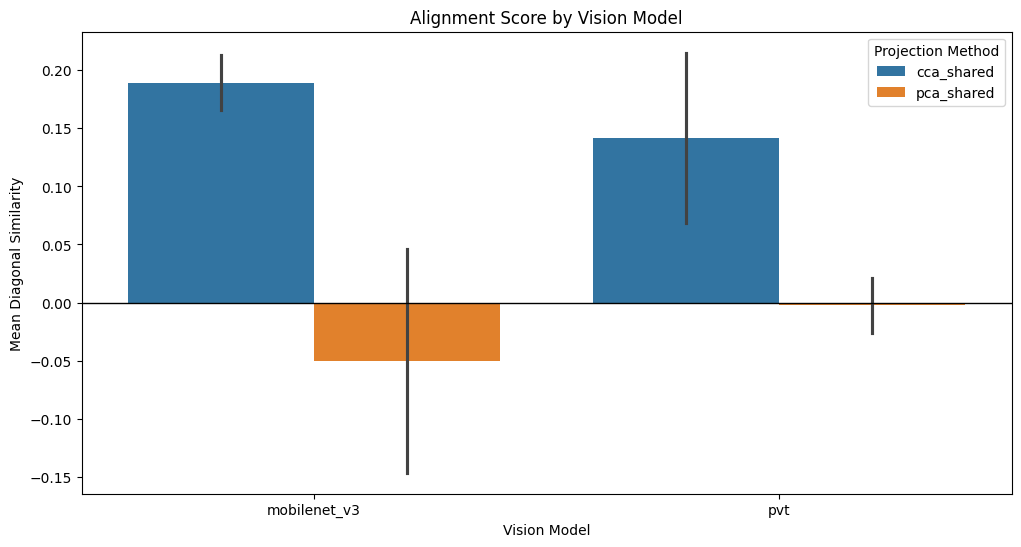

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(
    data=df_summary,
    x="vision_model",
    y="alignment_mean",
    hue="projection"
)

plt.title("Alignment Score by Vision Model")
plt.ylabel("Mean Diagonal Similarity")
plt.xlabel("Vision Model")
plt.legend(title="Projection Method")
plt.axhline(0, color="black", linewidth=1)
plt.show()


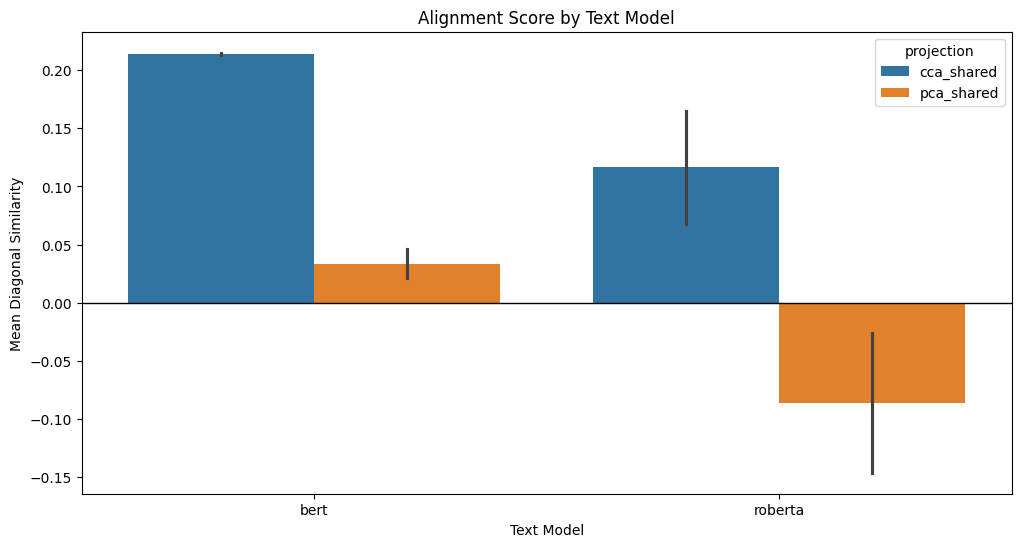

In [141]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=df_summary,
    x="text_model",
    y="alignment_mean",
    hue="projection"
)

plt.title("Alignment Score by Text Model")
plt.ylabel("Mean Diagonal Similarity")
plt.xlabel("Text Model")
plt.axhline(0, color="black", linewidth=1)
plt.show()
